# Notebook 01 — Exploration du dataset brut

Avant de faire quoi que ce soit, je voulais regarder les données telles quelles pour comprendre avec quoi on travaille. Ce notebook c'est juste l'exploration, le nettoyage sera fait dans le notebook 02.

## Section 0 — Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Section 1 — Chargement des données

In [5]:
df_brut = pd.read_csv("../data/raw/instagram_brut.csv")
print(df_brut.shape)

(797, 13)


J'ai chargé le dataset brut avec les imperfections introduites volontairement (NaN, valeurs aberrantes). On a 797 lignes et 13 colonnes. On ne touche pas encore aux données, c'est juste pour explorer.

## Section 2 — Premier aperçu

In [6]:
print(df_brut.head())

   edge_followed_by  edge_follow  username_length  username_has_number  \
0             0.001        0.257             13.0                    1   
1             0.000        0.958              9.0                    1   
2             0.000        0.253             12.0                    0   
3             0.000        0.977             10.0                    1   
4             0.000        0.321             11.0                    0   

   full_name_has_number  full_name_length  is_private  is_joined_recently  \
0                     1              13.0           0                   0   
1                     0               0.0           0                   1   
2                     0               0.0           0                   0   
3                     0               0.0           0                   0   
4                     0              11.0           1                   0   

   has_channel  is_business_account  has_guides  has_external_url  is_fake  
0            0 

In [7]:
print(df_brut.dtypes)

edge_followed_by        float64
edge_follow             float64
username_length         float64
username_has_number       int64
full_name_has_number      int64
full_name_length        float64
is_private                int64
is_joined_recently        int64
has_channel               int64
is_business_account       int64
has_guides                int64
has_external_url          int64
is_fake                   int64
dtype: object


In [8]:
print(df_brut.info())

<class 'pandas.DataFrame'>
RangeIndex: 797 entries, 0 to 796
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      782 non-null    float64
 1   edge_follow           773 non-null    float64
 2   username_length       758 non-null    float64
 3   username_has_number   797 non-null    int64  
 4   full_name_has_number  797 non-null    int64  
 5   full_name_length      758 non-null    float64
 6   is_private            797 non-null    int64  
 7   is_joined_recently    797 non-null    int64  
 8   has_channel           797 non-null    int64  
 9   is_business_account   797 non-null    int64  
 10  has_guides            797 non-null    int64  
 11  has_external_url      797 non-null    int64  
 12  is_fake               797 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 81.1 KB
None


À première vue la plupart des colonnes sont des entiers (variables binaires 0 ou 1). edge_followed_by et edge_follow sont en float (ce sont des ratios). Je remarque que edge_followed_by est en object alors qu'il devrait être en float — ça veut dire qu'il y a des valeurs non numériques dedans (les "N/A" qu'on a injectés). À traiter dans le preprocessing.

## Section 3 — Statistiques descriptives

In [9]:
print(df_brut.describe())

       edge_followed_by  edge_follow  username_length  username_has_number  \
count        782.000000   773.000000       758.000000           797.000000   
mean           0.002229     0.400338        16.761214             0.644918   
std            0.036174     0.293795        63.376460             0.478839   
min            0.000000     0.000000         5.000000             0.000000   
25%            0.000000     0.135000         9.000000             0.000000   
50%            0.000000     0.335000        11.000000             1.000000   
75%            0.000000     0.619000        14.000000             1.000000   
max            1.000000     1.000000       999.000000             1.000000   

       full_name_has_number  full_name_length  is_private  is_joined_recently  \
count            797.000000        758.000000  797.000000          797.000000   
mean               0.110414          8.506596    0.184442            0.360100   
std                0.313602         38.293200    0.388

Le tableau confirme que les colonnes binaires (is_private, has_channel, etc.) ont des valeurs entre 0 et 1. Pour username_length et full_name_length, je vois des max très élevés (999 et 700) qui sont clairement des valeurs aberrantes — un username de 999 caractères ça n'existe pas sur Instagram. À traiter plus tard.

## Section 4 — Valeurs manquantes

In [10]:
print(df_brut.isnull().sum())

edge_followed_by        15
edge_follow             24
username_length         39
username_has_number      0
full_name_has_number     0
full_name_length        39
is_private               0
is_joined_recently       0
has_channel              0
is_business_account      0
has_guides               0
has_external_url         0
is_fake                  0
dtype: int64


Plusieurs colonnes ont des NaN : username_length et full_name_length autour de 5%, edge_follow autour de 3%, et edge_followed_by aussi (les "N/A" que pandas a interprétés comme NaN). Les autres colonnes sont complètes. À traiter dans le notebook 02 avec un imputer comme on a vu en cours.

## Section 5 — La variable cible

In [11]:
freq = df_brut["is_fake"].value_counts()
print(freq)

is_fake
1    703
0     94
Name: count, dtype: int64


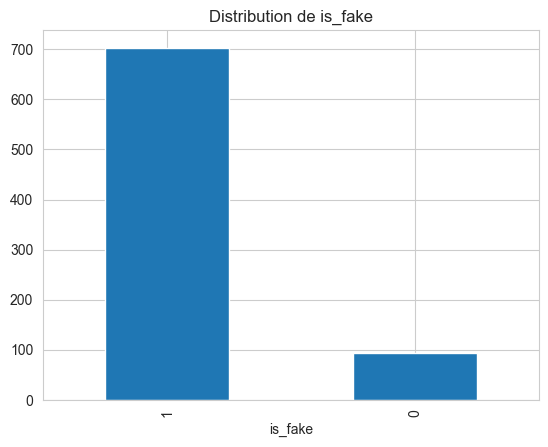

In [12]:
freq.plot(kind="bar")
plt.title("Distribution de is_fake")
plt.show()

Le déséquilibre est très fort : environ 88% de faux profils (is_fake=1) contre 12% de vrais (is_fake=0). Comme vu dans le chap 2, dans ce cas l'accuracy ne suffit pas — un modèle qui prédit "faux" tout le temps aurait déjà 88% sans rien apprendre. Il faudra surtout regarder le recall et le F1-score.

## Section 6 — Distribution des features numériques

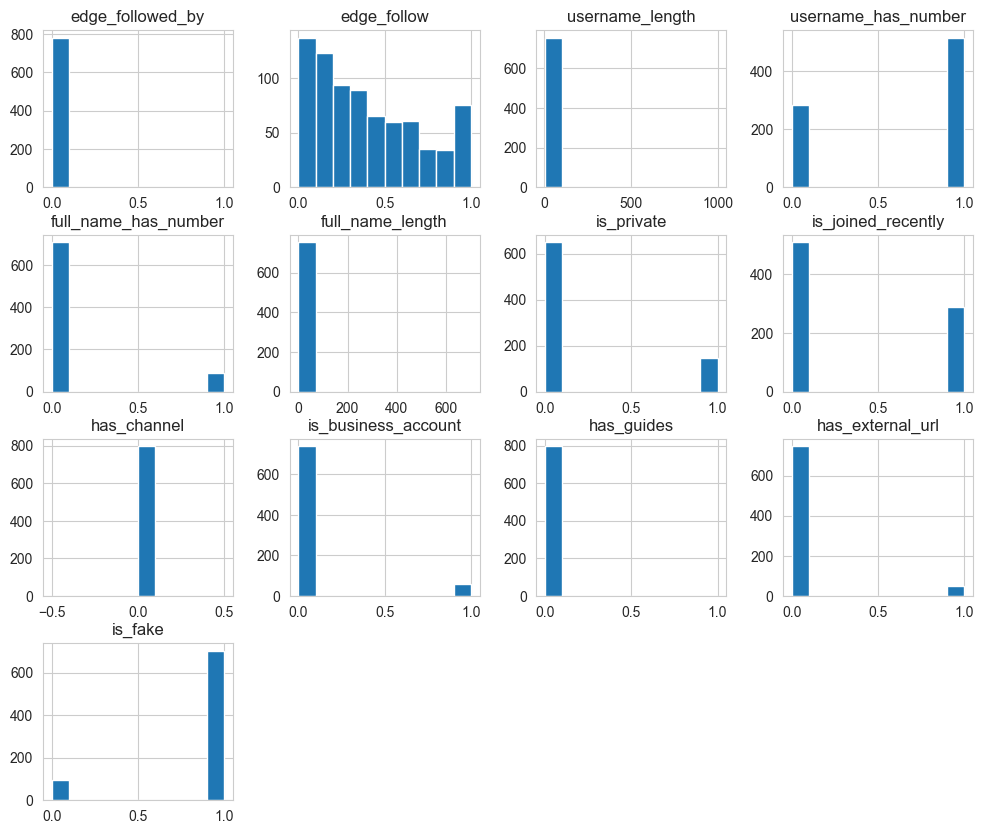

In [13]:
df_brut.hist(figsize=(12, 10))
plt.show()

Quelques observations : les colonnes binaires (is_private, has_channel, is_business_account, etc.) sont concentrées sur 0 ou 1, c'est logique. edge_followed_by et edge_follow ont la majorité des valeurs proches de 0 (ratios faibles), ce qui colle avec des faux profils peu actifs. Pour username_length et full_name_length, je vois des pics très isolés sur des valeurs élevées — ce sont les valeurs aberrantes qu'on a injectées, à confirmer avec les boxplots.

## Section 7 — Détection des valeurs aberrantes

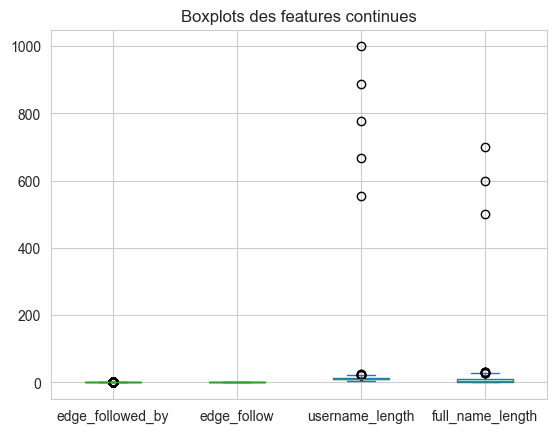

In [14]:
df_brut[["edge_followed_by", "edge_follow", "username_length", "full_name_length"]].plot.box()
plt.title("Boxplots des features continues")
plt.show()

Les boxplots confirment ce qu'on suspectait. username_length et full_name_length ont des valeurs aberrantes vraiment extrêmes (jusqu'à 999 et 700) — un username de 999 caractères n'existe pas sur Instagram, c'est forcément à traiter. edge_followed_by et edge_follow restent globalement entre 0 et 1 avec quelques points au-dessus.

## Section 8 — Matrice de corrélation

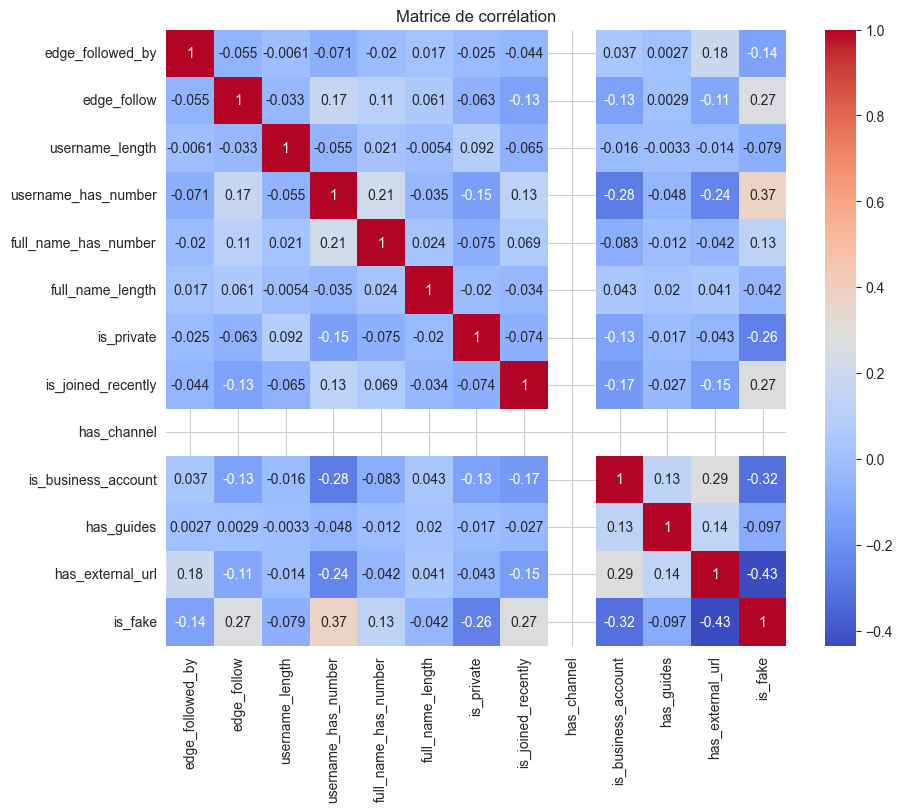

In [18]:
matr = df_brut.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

has_external_url       -0.434797
is_business_account    -0.316871
is_private             -0.257395
edge_followed_by       -0.136674
has_guides             -0.096930
username_length        -0.078811
full_name_length       -0.042098
full_name_has_number    0.128826
edge_follow             0.268295
is_joined_recently      0.274310
username_has_number     0.370868
is_fake                 1.000000
has_channel                  NaN
Name: is_fake, dtype: float64


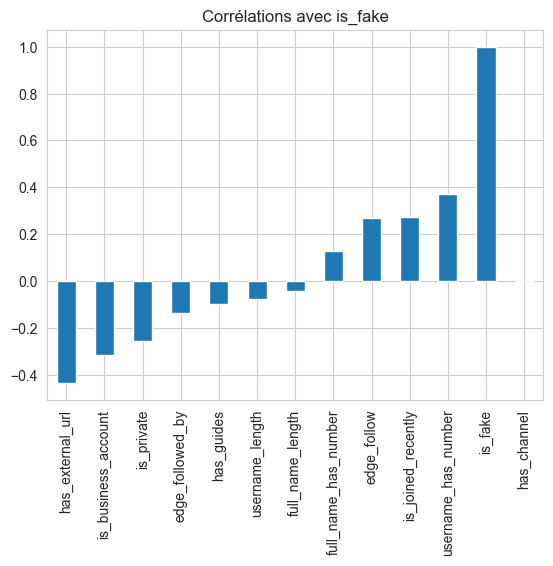

In [19]:
corr_cible = matr["is_fake"].sort_values()
print(corr_cible)
corr_cible.plot(kind="bar")
plt.title("Corrélations avec is_fake")
plt.show()

La heatmap montre les corrélations entre toutes les features. Plus c'est rouge foncé, plus la corrélation est positive (proche de 1). Plus c'est bleu foncé, plus elle est négative (proche de -1). Comme la matrice est dense avec 13 colonnes, j'ai aussi extrait juste la colonne is_fake et je l'ai affichée triée en barre pour mieux voir quelles features prédisent la cible. is_joined_recently est plutôt bien corrélé positivement avec is_fake — les faux profils sont souvent récents, ça fait sens. has_external_url aussi semble lié à is_fake (probablement les liens spam). À l'inverse, edge_followed_by est négativement corrélé avec is_fake : les vrais profils ont plus de followers. Comme vu dans le cours, plus la valeur est proche de 1 ou -1, plus la corrélation est forte.

## Section 9 — Comparaison vrais vs faux profils

In [20]:
df_vrai = df_brut[df_brut["is_fake"] == 0]
df_faux = df_brut[df_brut["is_fake"] == 1]

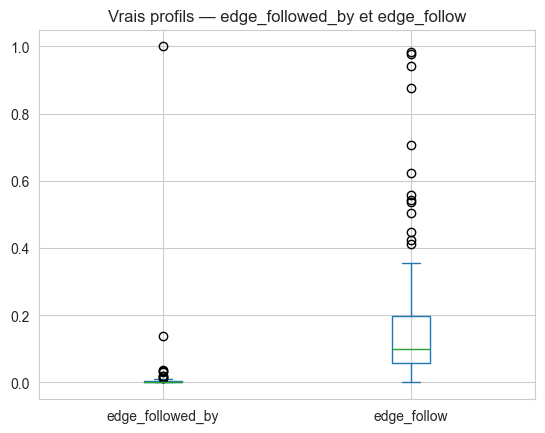

In [21]:
df_vrai[["edge_followed_by", "edge_follow"]].plot.box()
plt.title("Vrais profils — edge_followed_by et edge_follow")
plt.show()

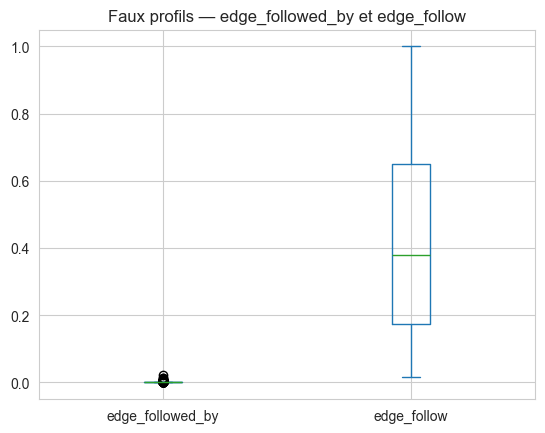

In [22]:
df_faux[["edge_followed_by", "edge_follow"]].plot.box()
plt.title("Faux profils — edge_followed_by et edge_follow")
plt.show()

En comparant les deux boxplots, on voit que les vrais profils (is_fake = 0) ont des edge_followed_by et edge_follow plus élevés que les faux : ils ont en général plus de followers et suivent plus de monde. C'est cohérent avec l'analyse de corrélation. Les features les plus utiles pour distinguer les classes semblent donc être edge_followed_by, edge_follow et is_joined_recently.

## Section 10 — Conclusion

Voilà ce que je retiens.

**Qualité des données** : il y a plusieurs choses à régler — des NaN sur 4 colonnes (entre 2% et 5%), des valeurs aberrantes très extrêmes sur username_length et full_name_length, et le type de edge_followed_by à corriger (object au lieu de float). Tout ça sera traité dans le notebook 02.

**Déséquilibre des classes** : 88% de faux profils contre 12% de vrais. Il faudra être vigilante sur les métriques (recall et F1 plutôt que l'accuracy seule).

**Features prometteuses** : d'après les corrélations et les boxplots, is_joined_recently, edge_followed_by et edge_follow semblent les plus discriminantes. On gardera quand même les autres pour laisser les modèles décider.

**Plan pour le notebook 02** : gérer les NaN avec un imputer, corriger le type de edge_followed_by, traiter les valeurs aberrantes, normaliser les colonnes continues avant la modélisation.